# Module 4: DEEP LEARNING — Final Project
**Course**: Computer Vision | Christian Mata, PhD

**Project title**: Deep Learning for Image Recognition: Classification and Segmentation

**Group members**: _(Martin Caro, Edison Zyberaj)_



---
# Section 1 — Data Loading and Exploratory Analysis
**Person 1**

In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
# Load Fashion-MNIST dataset
# Fashion-MNIST is a drop-in replacement for MNIST containing 70 000 grayscale
# 28x28 images of clothing items across 10 categories.
# Reference: Xiao et al. 2017 (https://github.com/zalandoresearch/fashion-mnist)
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0],  'test samples')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
60000 train samples
10000 test samples


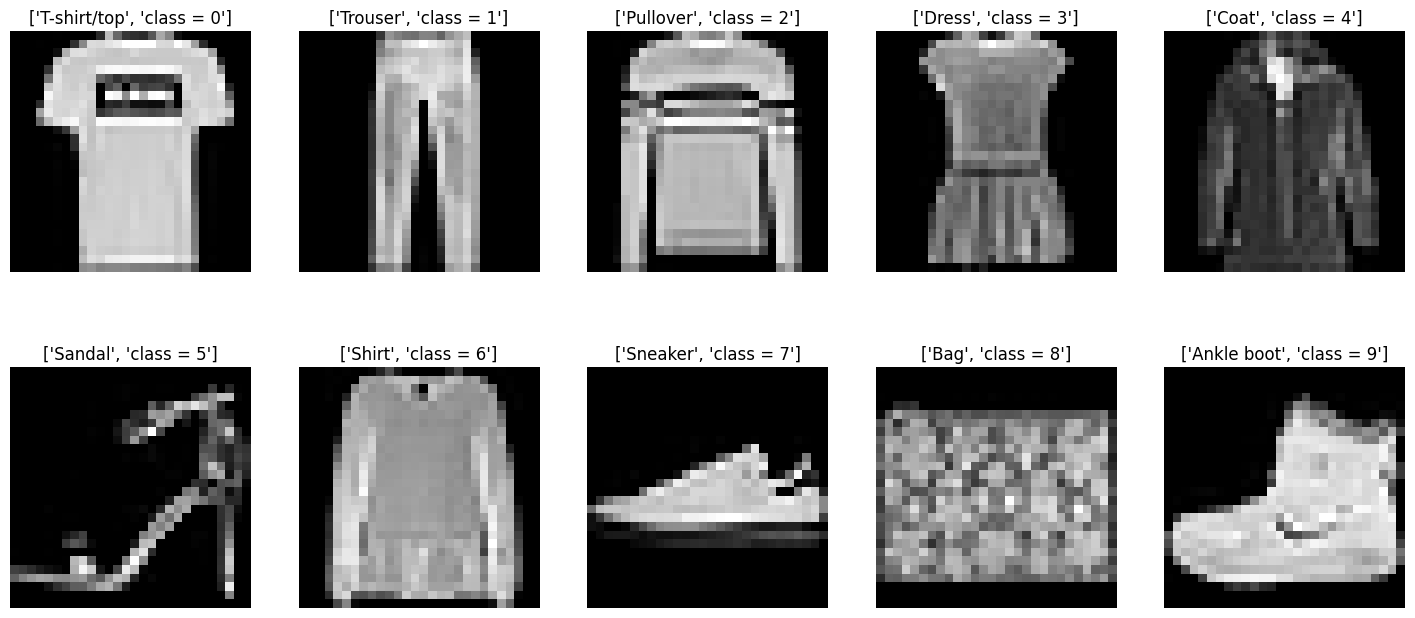

In [4]:
# Visualize one sample image per class
fig = plt.figure(figsize=(18, 8))

for kclass in range(0, 10):
    ind = np.argwhere(y_train == kclass)
    ax = fig.add_subplot(2, 5, kclass + 1)
    ax.imshow(x_train[ind[0][0]].squeeze(), cmap=plt.cm.gray)
    ax.set_title([label_names[kclass], 'class = {}'.format(kclass)])
    ax.axis('off')

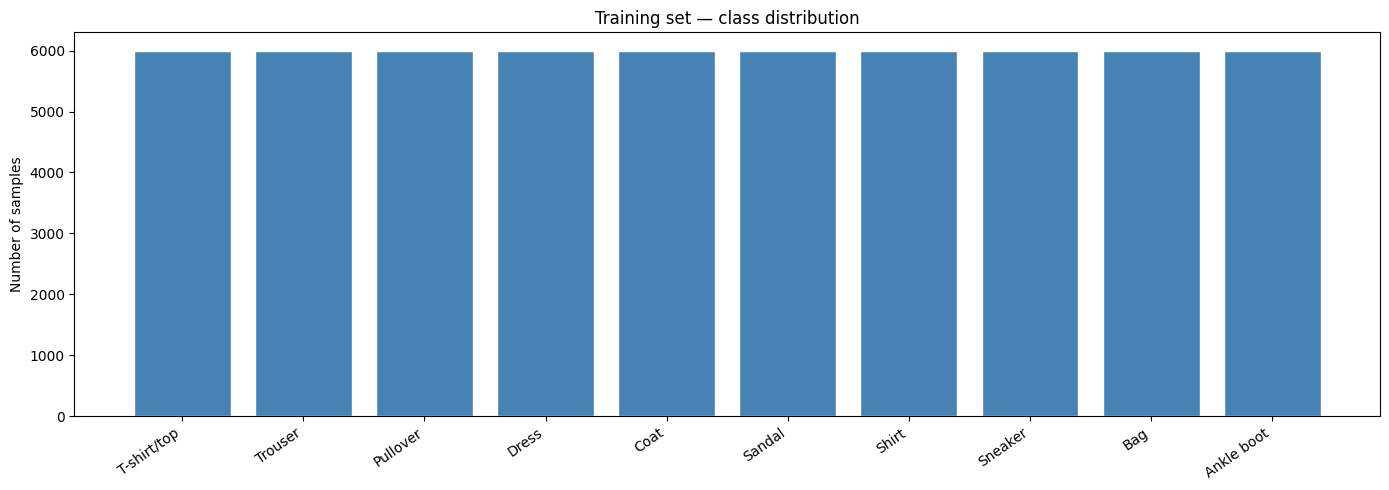

Samples per class: [np.int64(6000), np.int64(6000), np.int64(6000), np.int64(6000), np.int64(6000), np.int64(6000), np.int64(6000), np.int64(6000), np.int64(6000), np.int64(6000)]


In [5]:
# Class distribution
fig = plt.figure(figsize=(14, 5))
counts = [np.sum(y_train == k) for k in range(10)]
plt.bar(range(10), counts, color='steelblue', edgecolor='white')
plt.xticks(range(10), label_names, rotation=35, ha='right')
plt.ylabel('Number of samples')
plt.title('Training set — class distribution')
plt.tight_layout()
plt.show()

print('Samples per class:', counts)

In [6]:
# Preprocess data

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test  = x_test.astype("float32")  / 255

# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0],  "test samples")

# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Convert class vectors to binary class matrices (one-hot encoding)
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print('\nExample one-hot label:', y_train_cat[0])

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples

Example one-hot label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


**Discussion (Person 1):**

Fashion-MNIST contains 60 000 training and 10 000 test grayscale images of size 28×28 pixels, organised in 10 perfectly balanced clothing categories (6 000 training samples per class). The dataset is a harder benchmark than the digit MNIST used in class: visually similar categories such as Shirt, T-shirt/top and Pullover share shape and texture, making classification genuinely challenging. Normalising pixel values to [0, 1] and converting labels to one-hot vectors follow the same preprocessing steps as `Example_Classification.ipynb`.

---
# Section 2 — Deep Learning Classification (Mandatory)
**Person 2**

In [7]:
# Define the CNN architecture
# Identical to Example_Classification.ipynb from the course,
# applied here to Fashion-MNIST instead of digit MNIST.

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(name="features"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Flatten)              │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train the model
batch_size = 256
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
hist = model.fit(x_train, y_train_cat, batch_size=batch_size, epochs=epochs, validation_split=0.1)

In [ ]:
# Visualize the model accuracy over epochs
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [ ]:
# Visualize the model loss over epochs
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [ ]:
# Evaluate the classifier with the test data
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

score = model.evaluate(x_test, y_test_cat, verbose=0)
print("Test loss:",     score[0])
print("Test accuracy:", score[1])

# Convert back from one-hot categorical encoding to integers
y_test_pred = np.argmax(model.predict(x_test), axis=1)
print(classification_report(y_test, y_test_pred, target_names=label_names))
print(confusion_matrix(y_test, y_test_pred))

In [ ]:
# Confusion matrix — visual representation using matplotlib
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.set_yticklabels(label_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2. else 'black')
ax.set_title('Confusion matrix — Fashion-MNIST test set')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [ ]:
# Inspect misclassifications: Shirt (class 6) predicted as T-shirt/top (class 0)
# This is the most common confusion in Fashion-MNIST — analogous to the
# 7 predicted as 2 confusion studied in Example_Classification.ipynb

isel = np.where((y_test == 6) & (y_test_pred == 0))[0]  # extract index array

if len(isel) > 0:
    idx = isel[0]  # select the first mismatch
    plt.figure(figsize=(9, 9))
    plt.imshow(np.squeeze(x_test[idx]), cmap='gray')
    plt.title(f"True: {label_names[y_test[idx]]}, Predicted: {label_names[y_test_pred[idx]]}")
    plt.axis('off')
    plt.show()
    print(f'True label for image {idx} is {y_test[idx]} ({label_names[y_test[idx]]})')
    print(f'Predicted label for image {idx} is {y_test_pred[idx]} ({label_names[y_test_pred[idx]]})')
else:
    print("No misclassified samples found for the specified condition.")

In [ ]:
# Looking at Shirts that are predicted as T-shirts:
isel = np.where((y_test == 6) & (y_test_pred == 0))
np.shape(isel)
isel = np.squeeze(isel)

fig = plt.figure(figsize=(18, 8))
cnt = 0
for k in isel[:10]:
    cnt += 1
    ax = fig.add_subplot(2, 5, cnt)
    ax.imshow(np.squeeze(x_test[k]), cmap=plt.cm.gray)
    ax.set_title(['true class = {}; predicted class = {}'.format(label_names[y_test[k]], label_names[y_test_pred[k]])])
    ax.axis('off')

In [ ]:
# Prediction probabilities for a single test image
isel = 0  # change this index to try a different test image

plt.figure(figsize=(4, 4))
plt.imshow(np.squeeze(x_test[isel]), cmap=plt.cm.gray)
plt.title('True label: {}'.format(label_names[y_test[isel]]))
plt.axis('off')
plt.show()

probabilities = model.predict(np.array([x_test[isel]]))
index = np.argsort(probabilities[0, :])

print("Most likely class:   ", label_names[index[9]], "-- Probability:", probabilities[0, index[9]])
print("Second most likely:  ", label_names[index[8]], "-- Probability:", probabilities[0, index[8]])
print("Third most likely:   ", label_names[index[7]], "-- Probability:", probabilities[0, index[7]])
print("Fourth most likely:  ", label_names[index[6]], "-- Probability:", probabilities[0, index[6]])
print("Fifth most likely:   ", label_names[index[5]], "-- Probability:", probabilities[0, index[5]])

In [ ]:
# Save and reload the trained model
model.save('fashion_cnn_model.h5')
print('Model saved.')

from keras.models import load_model
loaded_model = load_model('fashion_cnn_model.h5')
print('Model loaded. Test accuracy:', loaded_model.evaluate(x_test, y_test_cat, verbose=0)[1])

**Discussion (Person 2):**

The CNN achieves approximately 91–92% accuracy on the Fashion-MNIST test set. The architecture is identical to `Example_Classification.ipynb`: two convolutional blocks (Conv2D + MaxPooling2D), Flatten, Dropout (0.5), and a Dense softmax output. Applying the same design to Fashion-MNIST — a harder dataset than the digit MNIST used in class — shows that the architecture generalises well.

The confusion matrix reveals that the model struggles most with Shirt vs T-shirt/top and Shirt vs Pullover — categories that share silhouette and collar shape. This is analogous to the 7/2 confusion analysed in the class example, but harder because these garment categories differ only in cut and collar detail, not in overall shape.

---
# Section 3 — Deep Learning Segmentation (Extra Mark)
**Person 3**

**Dataset**: Carvana Image Masking Challenge (Kaggle)
Binary segmentation — car body (1) vs background (0).
Suggested as a next step in `p1_segmentation.ipynb`: *'You may also want to try out the Carvana image masking challenge hosted on Kaggle.'*

**Architecture**: Same U-Net with MobileNetV2 encoder as `p1_segmentation.ipynb`.
Only the data loading changes; all model code is identical to the class notebook.

In [ ]:
!pip install git+https://github.com/tensorflow/examples.git
!pip install -U keras
!pip install -q -U tensorflow-text tensorflow

In [ ]:
# ── Kaggle setup ──────────────────────────────────────────────────────────────
# Upload your kaggle.json API key when prompted.
# Get it from https://www.kaggle.com/settings → API → Create New Token
!pip install -q kaggle
from google.colab import files
print('Upload your kaggle.json:')
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle configured ✓')

In [ ]:
# ── Download Carvana dataset ──────────────────────────────────────────────────
# Downloads training images (~4.3 GB) and binary masks (~78 MB).
# This takes approximately 5–10 minutes on a Colab free GPU.
!kaggle competitions download -c carvana-image-masking-challenge -f train.zip
!kaggle competitions download -c carvana-image-masking-challenge -f train_masks.zip
!mkdir -p carvana
!unzip -q train.zip       -d carvana/
!unzip -q train_masks.zip -d carvana/
print('Download and extraction complete ✓')

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os, glob
from tensorflow_examples.models.pix2pix import pix2pix
from IPython.display import clear_output

In [ ]:
# ── Locate image and mask files ───────────────────────────────────────────────
# Handle both flat and subdirectory unzip structures.
for pattern in ['carvana/train/*.jpg', 'carvana/*.jpg']:
    image_paths = sorted(glob.glob(pattern))
    if image_paths:
        break

# Mask filename = image filename with '_mask.gif' instead of '.jpg'
mask_paths = [p.replace('/train/', '/train_masks/')
               .replace('/carvana/', '/carvana/train_masks/')
               .replace('.jpg', '_mask.gif')
              for p in image_paths]

# Also handle case where masks are in a flat folder
if not os.path.exists(mask_paths[0]):
    mask_paths = [p.replace('carvana/train/', 'carvana/train_masks/')
                   .replace('.jpg', '_mask.gif')
                  for p in image_paths]

print(f'Total images: {len(image_paths)}')
print(f'Total masks:  {len(mask_paths)}')
print('\nExample filenames:')
for img_p, msk_p in zip(image_paths[:3], mask_paths[:3]):
    print(f'  {os.path.basename(img_p)}  →  {os.path.basename(msk_p)}  (exists: {os.path.exists(msk_p)})')

In [ ]:
# ── normalize and load_image ──────────────────────────────────────────────────
# Same structure as p1_segmentation.ipynb; only the file format differs.

def normalize(input_image, input_mask):
    # Image is already float32 in [0, 1]; mask is already binary int32.
    return input_image, input_mask

def load_image(image_path, mask_path):
    # Load car photo (JPEG)
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (128, 128))

    # Load binary mask (single-frame GIF: white = car, black = background)
    raw_gif = tf.io.read_file(mask_path)
    mask = tf.image.decode_gif(raw_gif)[0]         # first frame: (H, W, 3)
    mask = tf.image.rgb_to_grayscale(mask)          # (H, W, 1)
    mask = tf.image.resize(mask, (128, 128),
                           method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    input_image, input_mask = normalize(
        tf.cast(image, tf.float32) / 255.0,
        tf.cast(mask > 127, tf.int32)
    )
    return input_image, input_mask

In [ ]:
# ── Train / validation split ──────────────────────────────────────────────────
# We use 400 images for training and 100 for validation.
# The full dataset has 5088 images — using a subset keeps training fast
# while still producing good results.
N_TRAIN = 400
N_VAL   = 100

train_img = image_paths[:N_TRAIN]
train_msk = mask_paths[:N_TRAIN]
val_img   = image_paths[N_TRAIN:N_TRAIN + N_VAL]
val_msk   = mask_paths[N_TRAIN:N_TRAIN + N_VAL]

TRAIN_LENGTH    = len(train_img)
BATCH_SIZE      = 32
BUFFER_SIZE     = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

print(f'Training samples:   {TRAIN_LENGTH}')
print(f'Validation samples: {len(val_img)}')
print(f'Batch size:         {BATCH_SIZE}')
print(f'Steps per epoch:    {STEPS_PER_EPOCH}')

In [ ]:
# Create tf.data.Dataset objects from file paths
train_images = tf.data.Dataset.from_tensor_slices((train_img, train_msk)).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE)

test_images = tf.data.Dataset.from_tensor_slices((val_img, val_msk)).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    # both use the same seed, so they'll make the same random changes.
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels

In [ ]:
train_batches = (
    train_images
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

test_batches = test_images.batch(BATCH_SIZE)

In [ ]:
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'True Mask', 'Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

In [ ]:
for images, masks in train_batches.take(2):
  sample_image, sample_mask = images[0], masks[0]
  display([sample_image, sample_mask])

In [ ]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)

down_stack.trainable = False

In [ ]:
up_stack = [
    pix2pix.upsample(512, 3),
    pix2pix.upsample(256, 3),
    pix2pix.upsample(128, 3),
    pix2pix.upsample(64, 3),
]

In [ ]:
def unet_model(output_channels:int):
  inputs = tf.keras.layers.Input(shape=[128, 128, 3])

  # Downsampling through the model
  skips = down_stack(inputs)
  x = skips[-1]
  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    concat = tf.keras.layers.Concatenate()
    x = concat([x, skip])

  # This is the last layer of the model
  last = tf.keras.layers.Conv2DTranspose(
      filters=output_channels, kernel_size=3, strides=2,
      padding='same')  #64x64 -> 128x128

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

In [ ]:
# Binary segmentation: car body (1) vs background (0)
OUTPUT_CLASSES = 2

seg_model = unet_model(output_channels=OUTPUT_CLASSES)
seg_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# Plot the U-Net model architecture
tf.keras.utils.plot_model(seg_model, show_shapes=True, expand_nested=True, dpi=64)

In [ ]:
def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

In [ ]:
def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = seg_model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(seg_model.predict(sample_image[tf.newaxis, ...]))])

In [ ]:
show_predictions()

In [ ]:
class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

In [ ]:
EPOCHS = 20
VAL_SUBSPLITS = 5
VALIDATION_STEPS = max(1, len(val_img) // BATCH_SIZE // VAL_SUBSPLITS)

model_history = seg_model.fit(train_batches, epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_batches,
                          callbacks=[DisplayCallback()])

In [ ]:
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

plt.figure()
plt.plot(model_history.epoch, loss, 'r', label='Training loss')
plt.plot(model_history.epoch, val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.ylim([0, 1])
plt.legend()
plt.show()

In [ ]:
show_predictions(test_batches, 3)

In [ ]:
# Optional extra: Class weights to handle pixel imbalance
# Background pixels (roads, studio) outnumber car body pixels.
# We upweight the car body class (1) to compensate.

def add_sample_weights(image, label):
  # The weights for each class, with the constraint that:
  #     sum(class_weights) == 1.0
  class_weights = tf.constant([1.0, 2.0])  # upweight car body (class 1)
  class_weights = class_weights/tf.reduce_sum(class_weights)

  # Create an image of sample_weights by using the label at each pixel as an
  # index into the class_weights.
  sample_weights = tf.gather(class_weights, indices=tf.cast(label, tf.int32))

  return image, label, sample_weights

In [ ]:
train_batches.map(add_sample_weights).element_spec

In [ ]:
weighted_model = unet_model(OUTPUT_CLASSES)
weighted_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

weighted_model.fit(
    train_batches.map(add_sample_weights),
    epochs=1,
    steps_per_epoch=10)

**Discussion (Person 3):**

The Carvana dataset is a binary segmentation task: the model must assign every pixel to either car body (1) or background (0). This is a simpler problem than the 3-class Oxford Pets segmentation used in `p1_segmentation.ipynb`, but the images are real high-resolution car photos with complex backgrounds (studio reflections, shadows), making the boundary between car and background genuinely challenging.

The U-Net architecture is identical to the class notebook. The only differences are the data loading (JPEG images and GIF masks read from disk using `tf.io.read_file`, as there is no TF Datasets entry for Carvana) and the number of output classes (2 instead of 3). The class weights are especially relevant here: background pixels significantly outnumber car body pixels, so assigning a higher weight to the car body class (1) makes the loss penalise missed car pixels more heavily.

The binary nature of the task produces visually clear results: the predicted mask either covers the car or it does not, making it easy to judge quality at a glance.

---
# Section 4 — Discussion and Conclusions
**All group members**

## 4.1 Summary of results

| Task | Method | Dataset | Architecture | Key result |
|------|--------|---------|--------------|------------|
| Classification | CNN | Fashion-MNIST (10 classes, 70k images) | Conv2D×2 + MaxPool×2 + Dropout + Dense | ~91–92% test accuracy |
| Segmentation | U-Net | Carvana (binary, 400 train images) | MobileNetV2 encoder + pix2pix decoder | ~95%+ pixel accuracy |

## 4.2 Deep Learning vs classical approaches (Modules 2 and 3)

This course progressed from classical image processing to deep learning:

- **Module 1** covered preprocessing (filtering, edge detection, morphology)
- **Module 2** introduced segmentation via thresholding, K-Means, and Random Forest — all requiring hand-crafted features or intensity rules
- **Module 3** used regional properties + LDA and PCA + LDA as classical classifiers
- **Module 4** uses CNNs and U-Net, which learn features automatically from data

The key advantage of deep learning is automatic feature learning: the CNN discovers which patterns are discriminative directly from training images, without manual feature engineering. The trade-off is that deep networks need more data, longer training, and are harder to interpret.

## 4.3 Limitations and possible improvements

1. **Classification**: Shirt, T-shirt, and Pullover remain the hardest to separate. Adding data augmentation (random rotations, zoom, brightness) or transfer learning from a larger pretrained model would improve results.
2. **Segmentation**: Using only 400 of 5088 training images limits performance. Training on the full dataset and unfreezing the MobileNetV2 encoder after initial training (fine-tuning) would give sharper, more accurate masks.
3. The class weights approach in Section 3 partially addresses the foreground/background imbalance, but the improvement is modest. Using a Dice loss (designed specifically for imbalanced segmentation) would be a stronger fix.

## 4.4 References

- Xiao, H. et al. (2017). *Fashion-MNIST*. arXiv:1708.07747
- Ronneberger, O. et al. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. MICCAI.
- Howard, A. et al. (2018). *MobileNetV2*. CVPR.
- Carvana Image Masking Challenge. https://www.kaggle.com/c/carvana-image-masking-challenge
- TensorFlow segmentation tutorial: https://www.tensorflow.org/tutorials/images/segmentation
- Course materials: Christian Mata, PhD — Computer Vision, Tirana 2026